# 实验一 K近邻算法

K近邻（KNN）是“惰性学习”的典型代表，它把全部样本直接当作“参考库”，不做显式训练，而是等到新样本到来时才临时“翻书”找邻居。
整个决策过程也分三步：

- 当特征空间维度较低且样本分布清晰时，只需按欧氏距离取 k 个最近邻，多数投票即可把类别划分开——这相当于用“局部平面”拼出决策边界。
- 当数据重叠或噪声较多时，仍按距离投票，但允许给不同邻居加权（如距离越近权重越大），相当于引入“软投票”来缓解硬边界过拟合。
- “距离核”思想把度量从欧氏空间升到高维隐空间——例如用 Mahalanobis 距离、汉明距离或学到的度量矩阵，使原本纠缠的类别在新距离下变得线性可分；这种“度量学习”技巧让 KNN 也能画出复杂的非线性边界，而无需显式训练模型参数。

**学习目标:**
1. 理解并实现上述提到的KNN的概念
2. 将KNN应用于海蛞蝓的年龄预测


## 海蛞蝓年龄预测问题陈述
海蛞蝓的年龄可以通过切开其壳并数壳上的环数来确定。在海蛞蝓数据集中，你可以找到大量鲍鱼的年龄测量值，以及许多其他物理测量值。

本项目的目标是建立一个模型，仅凭其他物理测量值就能预测海蛞蝓的年龄，从而让研究人员无需切开壳数环即可估计其年龄。

你将应用 k 近邻（kNN）算法，力求获得尽可能接近真实年龄的预测得分。


In [13]:
## 导入数据
import pandas as pd
abalone = pd.read_csv("abalone.csv")

In [14]:
abalone

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.1200,8
...,...,...,...,...,...,...,...,...,...
4171,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4172,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4173,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4174,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


但还有一件事需要处理：应该把“Sex”（性别）列删掉。本次练习的目标是仅用物理测量值来预测海蛞蝓的年龄，而性别并非纯粹的物理量，因此需将其从数据集中移除。可用 .drop 方法删除 Sex 列：

In [15]:
abalone = abalone.drop("Sex", axis=1)

## 1. 数据展示

在开展机器学习工作时，必须对自己手中的数据有基本认识。不必深入细节，这里先给出一些探索性统计与图表，快速扫一眼即可。

### 1.1 直方图

本次任务的目标变量是 Rings（环数），因此从它开始。画一张直方图，就能迅速了解年龄大致落在哪些区间：

直方图显示，数据集中大多数海蛞蝓的环数集中在 5–15 之间，但最高可达 25 环。年龄较大的海蛞蝓在样本中占比偏低，这符合直觉——自然种群年龄分布通常呈这种右偏形态。

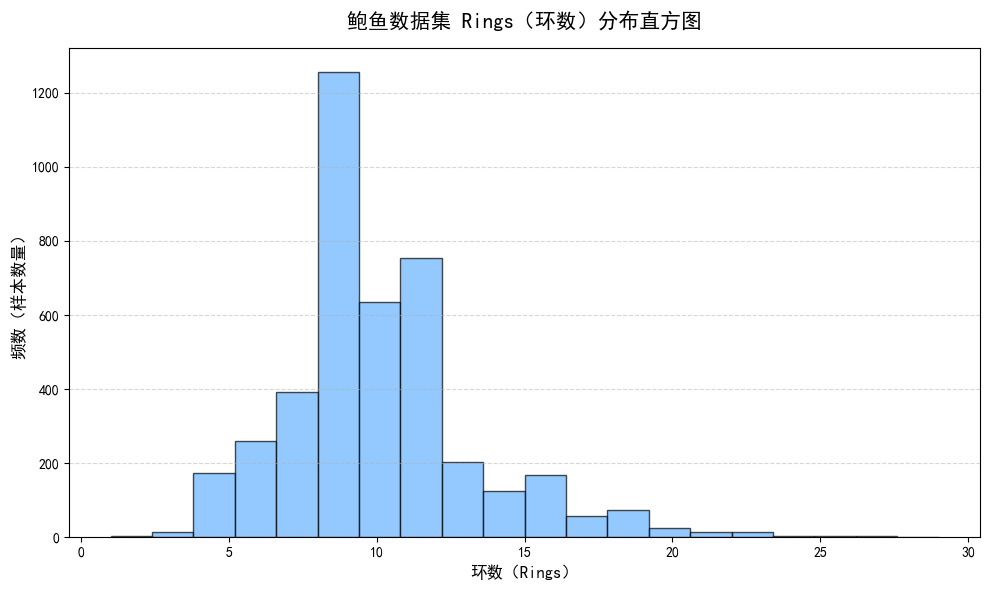

In [16]:
import matplotlib.pyplot as plt
#TODO: 请在下方填入代码，绘制 Rings 的直方图
# 1. 导入数据并删除Sex列
abalone = pd.read_csv("abalone.csv")
abalone = abalone.drop("Sex", axis=1)  # 移除性别列，仅保留数值特征

# 2. 基础配置（解决中文显示问题）
plt.rcParams["font.sans-serif"] = ["SimHei"]  # Windows系统
# plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  # macOS系统
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常

# 3. 绘制Rings列直方图
plt.figure(figsize=(10, 6), dpi=100)  # 设置画布大小和分辨率

# 核心：绘制直方图
plt.hist(
    abalone["Rings"],  # 数据源：Rings列
    bins=20,  # 组数，适配Rings分布特点
    edgecolor="black",  # 柱子边框，增强区分度
    alpha=0.7,  # 透明度
    color="#66b3ff"  # 柱子填充色
)

# 4. 添加图表标签和标题
plt.title("鲍鱼数据集 Rings（环数）分布直方图", fontsize=15, pad=15)
plt.xlabel("环数（Rings）", fontsize=12)
plt.ylabel("频数（样本数量）", fontsize=12)

# 5. 优化样式
plt.grid(axis="y", linestyle="--", alpha=0.5)  # 仅添加y轴网格线
plt.tight_layout()  # 自动调整布局，防止标签截断

# 6. 显示图表
plt.show()
pass

### 1.2 相关性分析

第二项值得探索的内容是：看看哪些变量（如果有的话）与年龄高度相关。

若某个自变量与目标变量呈强相关，那就是好兆头，说明物理测量值确实与年龄存在关联。你可以在 correlation_matrix 中查看完整的相关系数矩阵。最关键的自然是与目标变量 Rings（环数） 的相关性。提取这些相关系数的方法如下：

In [17]:
#TODO: 请在下方填入代码，计算 Rings 的相关性系数
# 计算相关系数矩阵
correlation_matrix = abalone.corr()

# 提取 Rings 与其他变量的相关系数
rings_correlation = correlation_matrix["Rings"]

# 打印结果（便于查看）
print("各变量与 Rings 的相关系数：")
print(rings_correlation)
pass    

各变量与 Rings 的相关系数：
Length            0.557123
Diameter          0.575005
Height            0.558109
Whole weight      0.540818
Shucked weight    0.421256
Viscera weight    0.504274
Shell weight      0.628031
Rings             1.000000
Name: Rings, dtype: float64


现在来看 Rings 与其他变量的相关系数。系数越接近 1，相关性越强。

可以得出：成年海蛞蝓的物理测量值与年龄确实存在一定相关性，但也不算高。若相关性极高，建模过程往往会非常顺利；而在这里，你需要亲自尝试，看看用 kNN 算法究竟能拿到怎样的结果。

## 2. X, Y数据生成

现在，为了在 NumPy 中寻找最近邻，回到海蛞蝓数据集。如前所述，你需要在自变量构成的向量上定义距离，因此应先把 pandas DataFrame 转成 NumPy 数组，使用 .values 属性即可：

In [18]:
X = abalone.drop("Rings", axis=1)
X = X.values
y = abalone["Rings"]
y = y.values


这段代码生成了两个对象：X 和 y，它们分别存储了你的数据。

- X 是模型的自变量（特征矩阵）；
- y 是模型的因变量（目标向量）。

注意这里 X 用大写字母，而 y 用小写字母——机器学习代码里常这么做，因为数学惯例里矩阵用粗体大写，向量用粗体小写，代码风格也就沿袭了这一写法。

现在，你可以用 k = 3 的 kNN 模型，对一条具有下列物理测量值的新海蛞蝓进行预测：

| 变量    | 数值       |
| ----- | -------- |
| 长度    | 0.569552 |
| 直径    | 0.446407 |
| 高度    | 0.154437 |
| 总重量   | 1.016849 |
| 去壳后重量 | 0.439051 |
| 内脏重量  | 0.222526 |
| 壳重    | 0.291208 |

In [19]:
import numpy as np
new_data_point = np.array([
    0.569552,
    0.446407,
    0.154437,
    1.016849,
    0.439051,
    0.222526,
    0.291208,
])

## 3. 距离计算

下一步是用下面的代码，计算这一新数据点与海蛞蝓数据集中每一个样本点之间的距离（欧式距离）：

In [20]:
#TODO: 请在下方填入代码，计算新数据点与数据集中每个样本点的距离
# 步骤1：计算差值 → 步骤2：平方 → 步骤3：按行求和 → 步骤4：开根号
distances = np.sqrt(np.sum((X - new_data_point) ** 2, axis=1))

# 打印前5个距离（验证结果）
print("前5个样本与新数据点的欧式距离：")
print(distances[:5])
pass

前5个样本与新数据点的欧式距离：
[0.9518455  0.40573594 0.59618172 0.9849569  0.79229506]


现在你得到了一个距离向量，接下来要找出 **距离最近的 3 个邻居**。  
为此，需要先拿到最小距离对应的样本编号。  
可以用 `.argsort()` 方法把数组按升序排列，然后取前 k 个元素，就能得到 k 个最近邻的索引：

In [21]:
k = 3
#TODO: 请在下方填入代码，找出 k 个最近邻的索引
nearest_neighbor_ids = np.argsort(distances)[:k]  # 排序后取前3个索引
print("3 个最近邻的索引为：", nearest_neighbor_ids)

3 个最近邻的索引为： [4044 1901 1643]


这样你就找到了与 **new_data_point** 最接近的 3 个邻居。下一段你将看到，如何把这些邻居的信息转换成对新点的年龄估计。

## 4. 投票或取平均  

已经拿到 3 个最近邻的索引后，下一步就是把它们“合成”一个对新鲍鱼的年龄预测。

首先，取出这 3 个邻居的真实环数（ground truth）：

In [22]:
nearest_neighbor_rings = y[nearest_neighbor_ids]
nearest_neighbor_rings

array([ 9, 11, 10])

现在你已经拿到了这三个邻居的值，接下来要把它们“合并”成对新数据点的预测。  
在回归与分类任务中，这种“合并邻居”的方式并不相同：

**回归问题取平均**：在回归问题中，目标变量是数值型；把多个邻居合并成一个预测值，只需对它们的目标变量取平均即可：

In [23]:
#TODO: 请在下方填入代码，得到模型预测值prediction
prediction = np.mean(nearest_neighbor_rings)
print(f"The predicted number of rings is {prediction:.2f}.")

The predicted number of rings is 10.00.


你会得到预测值 **10**。  
这意味着，用 3-最近邻模型预测这条海蛞蝓的年龄为 **10 环**。  